# Visualising recordings outside of djimaging

- to check things

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle
import stackview as sv

from djimaging.utils.scanm import read_smp_utils

In [2]:
# Define folder to load and save files
image_data = "/gpfs01/euler/data/Data/Salomon/cin_01_25_m/ACs/20251023/1/Raw/"

In [4]:
# Define a file list
file_list = os.listdir(image_data)

# Only include highresolution images
file_list_recordings = [filename for filename in file_list 
                            if filename.endswith(".smp")]
file_list_recordings

['M1_LR_t_XY7_lchirp_C2.smp',
 'M1_LR_t_XY8_chirp_DETANO.smp',
 'M1_LR_t_XY7_mb_C1.smp',
 'M1_LR_t_XY8_lchirp_DETANO.smp',
 'M1_LR_t_XY7_chirp_C1.smp',
 'M1_LR_t_XY8_mb_C1.smp',
 'M1_LR_t_XY7_lchirp_C1.smp',
 'M1_LR_t_XY8_lchirp_C1.smp',
 'M1_LR_t_XY8_chirp_C1.smp',
 'M1_LR_t_XY8_mb_DETANO.smp',
 'M1_LR_t_XY7_hr.smp',
 'M1_LR_t_XY8_hr.smp',
 'M1_LR_t_XY8_zstack.smp',
 'M1_LR_t_XY7_chirp_C2.smp',
 'M1_LR_t_XY7_mb_C2.smp',
 'M1_LR_t_XY7_zstack.smp']

In [ ]:
image = read_smp_utils.load_all_stacks_and_wparams

### Visualise data before and after DETA/NO treatment
- to check whether ROIs can be easily paired images before and after DETA/NO treatment will be visualised
- usually move around the Z-stack to have a C1 recording of both fields before the DETA/NO recording

In [11]:
file_list_filtered = [filename for filename in file_list if "chirp" in filename and filename.endswith(".smp")]
file_list_filtered

['M1_LR_t_XY8_chirp_DETANO.smp',
 'M1_LR_v_XY6_chirp_DETANO.smp',
 'M1_LR_n_XY4_chirp_C1.smp',
 'M1_LR_d_XY1_chirp_DETANO.smp',
 'M1_LR_v_XY6_chirp_C1.smp',
 'M1_LR_v_XY5_chirp_C1.smp',
 'M1_LR_n_XY3_chirp_C1.smp',
 'M1_LR_n_XY4_chirp_DETANO.smp',
 'M1_LR_t_XY7_chirp_DETANO.smp',
 'M1_LR_d_XY2_chirp_C1.smp',
 'M1_LR_t_XY7_chirp_C1.smp',
 'M1_LR_n_XY3_chirp_DETANO.smp',
 'M1_LR_d_XY1_chirp.smp',
 'M1_LR_v_XY5_chirp_DETANO.smp',
 'M1_LR_t_XY8_chirp_C1.smp']

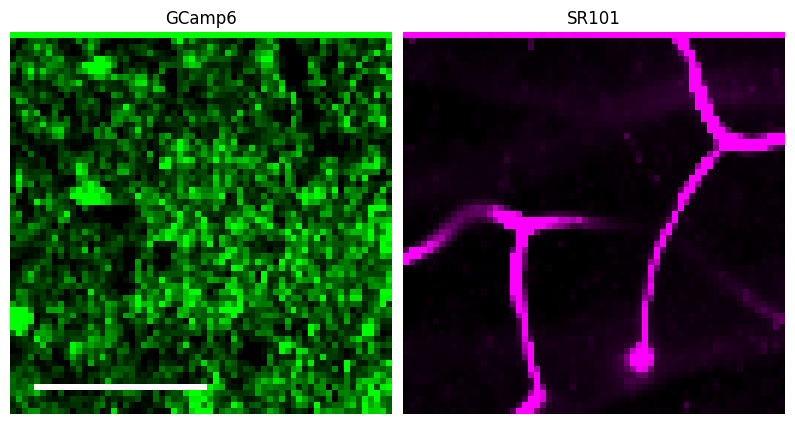

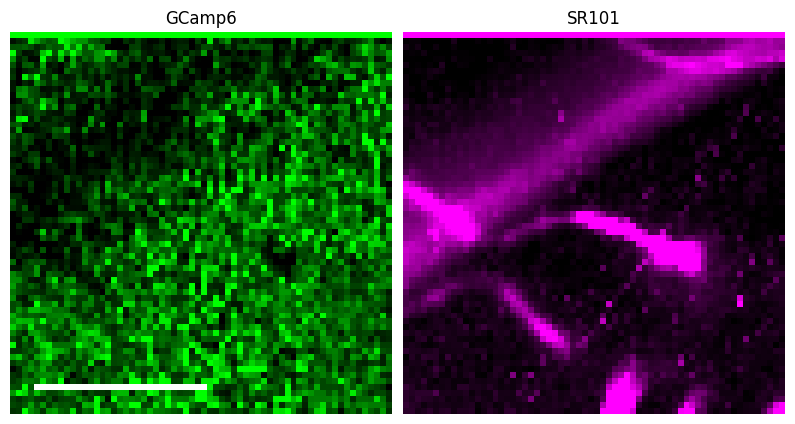

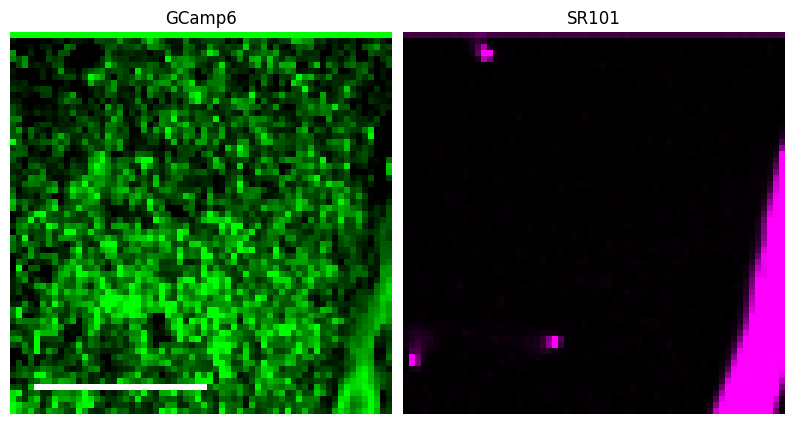

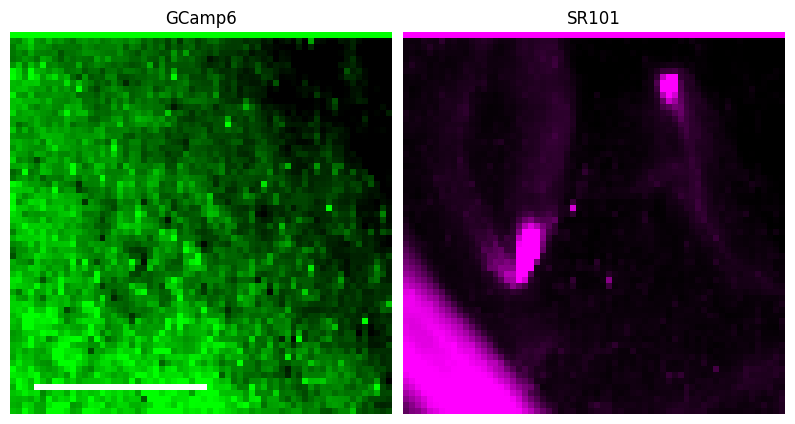

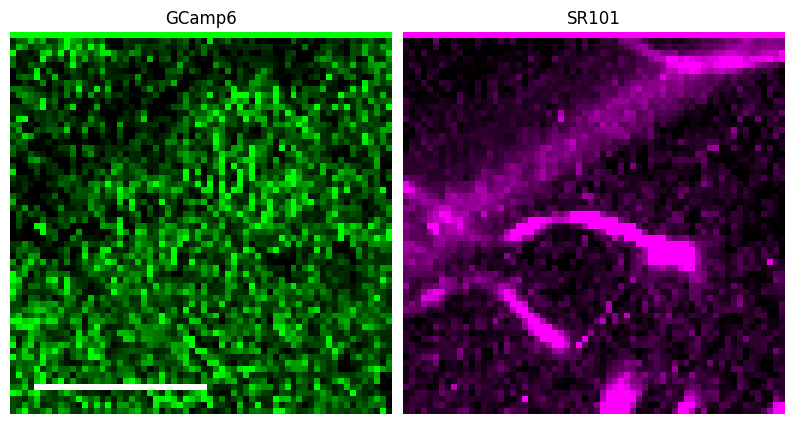

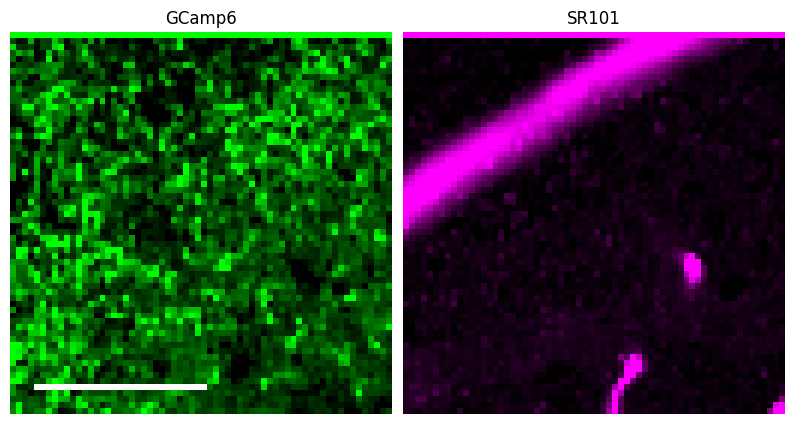

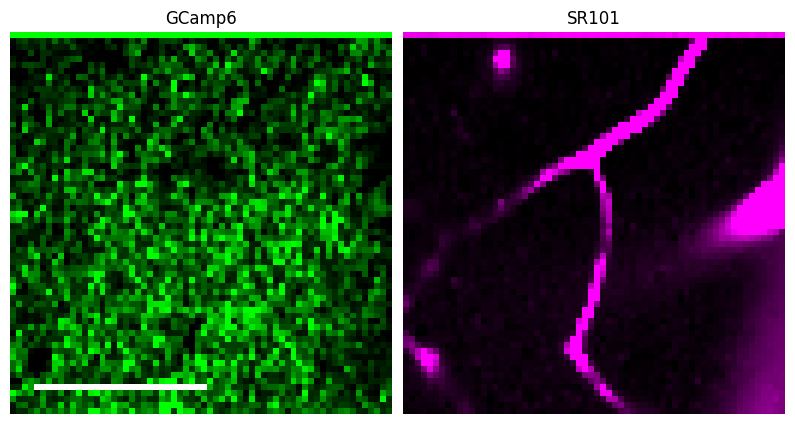

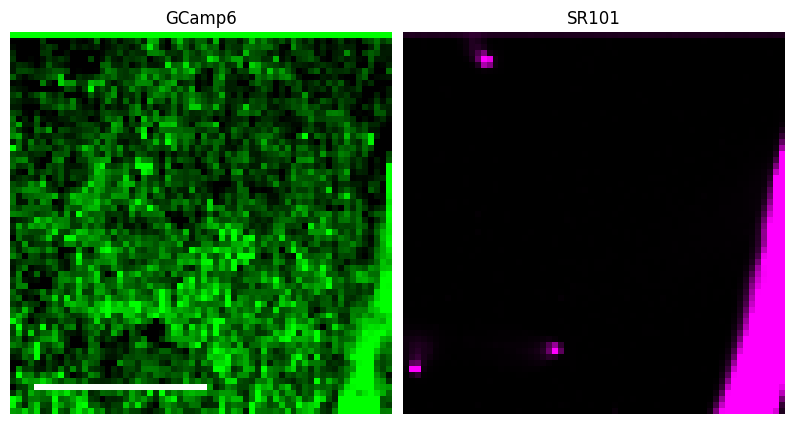

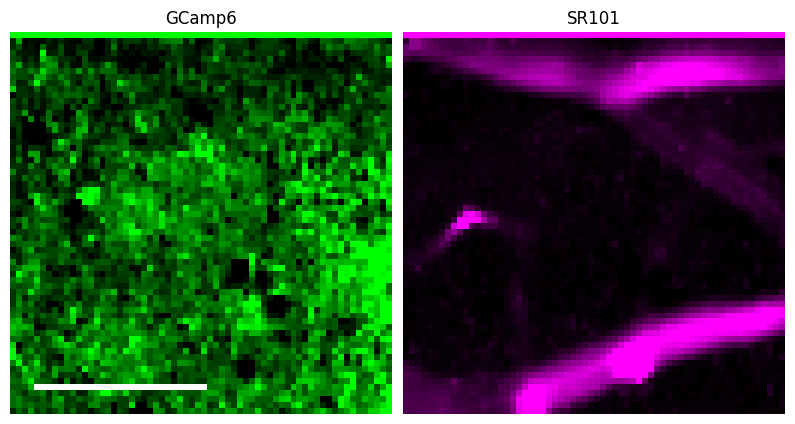

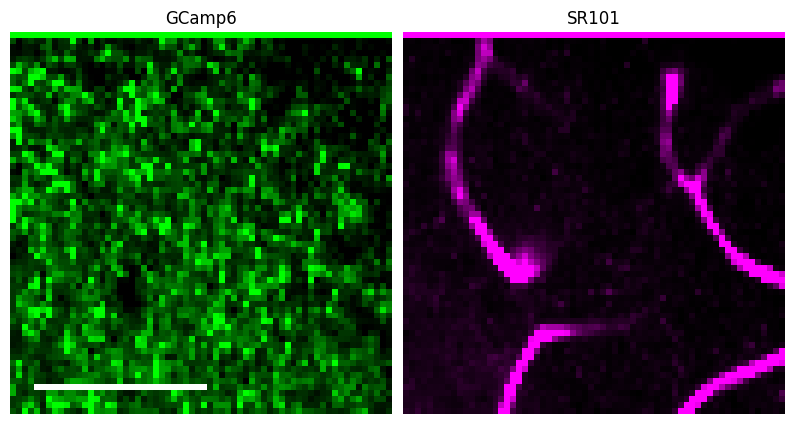

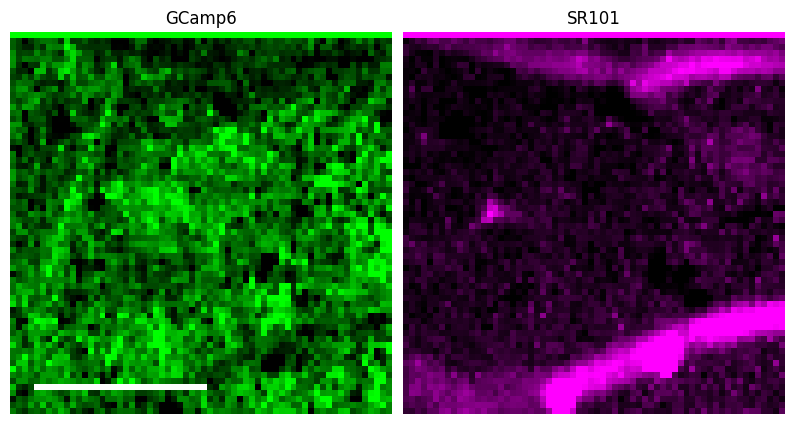

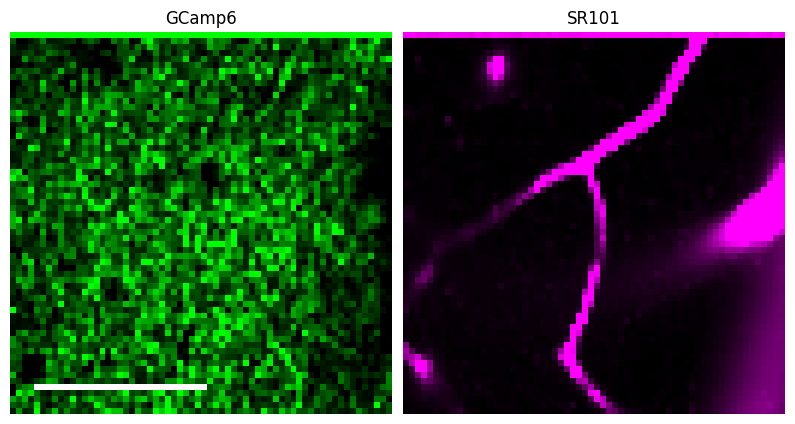

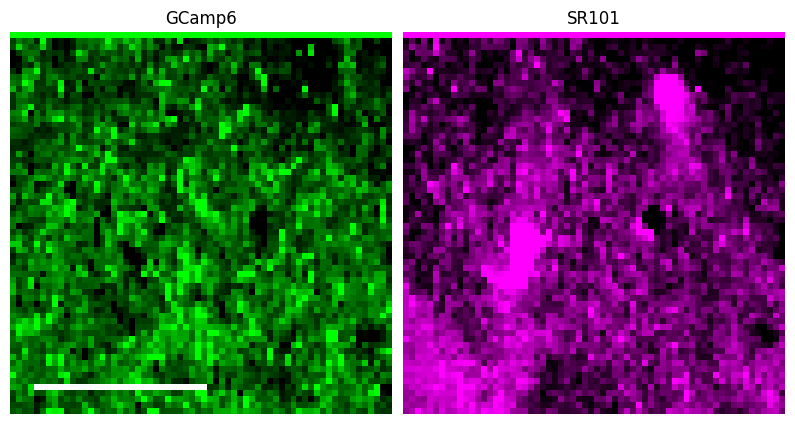

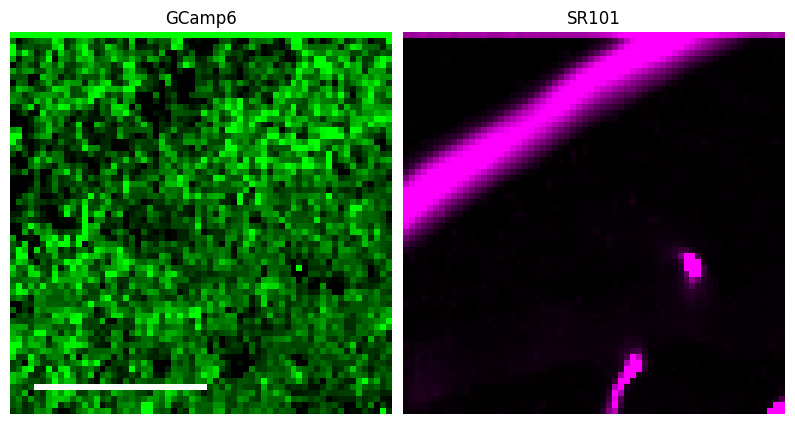

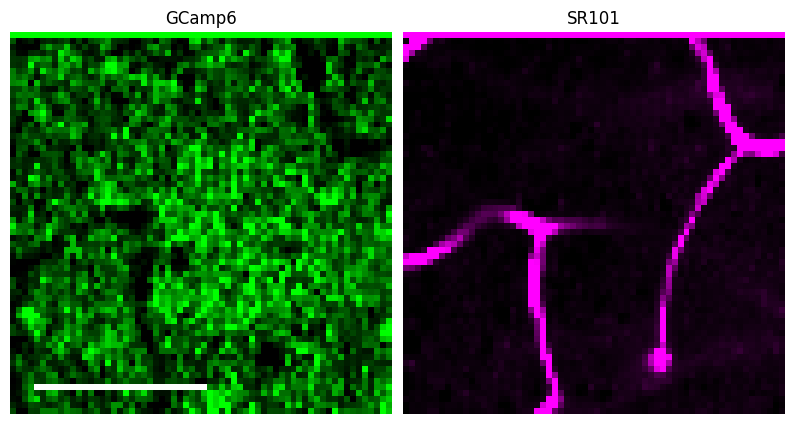

In [14]:
# For loop
for file_name in file_list_filtered:

    # Show file name to match image
    #print(file_name)

    # Load image
    image = read_smp_utils.load_all_stacks_and_wparams(image_data + file_name)

    # Calculate 1 and 99 intensity percentile of both channels
    p1_ch0 = np.percentile(np.mean(image[0]["wDataCh0"], axis=2), 5)
    p99_ch0 = np.percentile(np.mean(image[0]["wDataCh0"], axis=2), 95)

    p1_ch1 = np.percentile(np.mean(image[0]["wDataCh1"], axis=2), 5)
    p99_ch1 = np.percentile(np.mean(image[0]["wDataCh1"], axis=2), 95)

    # Define a scale bar with the above mentioned function
    scale_bar, cmap = scale_bar_image(image=np.mean(image[0]["wDataCh0"], axis=2),
                                      micron_length=1.71875,
                                      scale_length=50,
                                      thickness=1)

    # Show the image data of both channels
    fig, axs = plt.subplots(1, 2, figsize=(10, 10))
    
    # Show OGB-1
    sv.imshow(np.mean(image[0]["wDataCh0"], axis=2),
              colormap="pure_green",
              min_display_intensity=p1_ch0,
              max_display_intensity=p99_ch0,
              plot=axs[0])

    # Show scale bar
    sv.imshow(scale_bar,
              plot=axs[0],
              colormap=cmap)

    # Show SR101
    sv.imshow(np.mean(image[0]["wDataCh1"], axis=2),
              colormap="pure_magenta",
              min_display_intensity=p1_ch1,
              max_display_intensity=p99_ch1,
              plot=axs[1])

    # Adjust the subplots
    plt.subplots_adjust(wspace=0.03)
    plt.title(file_name)
    axs[0].set_title("GCamp6")
    axs[1].set_title("SR101")

    # Save the adjusted images
    file_name_clean = file_name.removesuffix(".smp") # Remove suffix, .smp not supported for microfilm
    plt.savefig(plots + file_name_clean + ".png",
                bbox_inches="tight",
                dpi=300)

### Code for micropanel (can be used later)

In [6]:
# def stack_image_data(image_data, channels=["wDataCh0", "wDataCh1"]):

#     extracted_channels = [np.array(image_data[0][ch].mean(axis=2)) for ch in channels]
#     stacked_channels = np.stack(extracted_channels, axis=2)

#     return stacked_channels

In [7]:
# lookup_tables = ["pure_green", "pure_magenta"]

# # For loop
# for file_name in file_list_highres_images:

#     # Load image
#     image = read_smp_utils.load_all_stacks_and_wparams(image_data + file_name)

#     # Calculate 1 and 99 percentile
#     p1_ch0 = np.percentile(np.mean(image[0]["wDataCh0"], axis=2), 1)
#     p99_ch0 = np.percentile(np.mean(image[0]["wDataCh0"], axis=2), 99)

#     p1_ch1 = np.percentile(np.mean(image[0]["wDataCh1"], axis=2), 1)
#     p99_ch1 = np.percentile(np.mean(image[0]["wDataCh1"], axis=2), 99)

#     intensity_ranges = [[p1_ch0, p99_ch0], [p1_ch1, p99_ch1]]

#     stacked_image = stack_image_data(image_data=image)
#     stacked_image = np.transpose(stacked_image[8:, :, :], (2, 0, 1))

#     composite = microshow(stacked_image, cmaps=lookup_tables, limits=intensity_ranges)